In [1]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

print("Libraries imported successfully")


Libraries imported successfully


In [2]:
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

rf_model = joblib.load("random_forest_model_tuned.pkl")
svm_model = joblib.load("svm_model.pkl")

print("Data and models loaded")


Data and models loaded


In [3]:
rf_pred = rf_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

print("Predictions generated")


Predictions generated


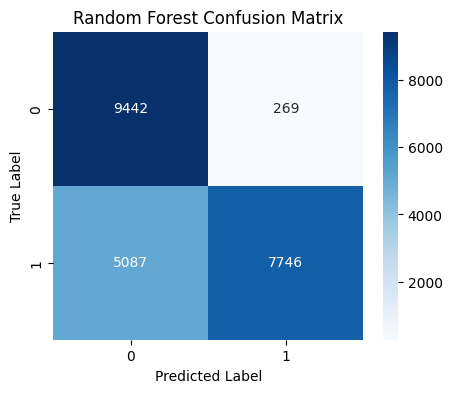

In [4]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


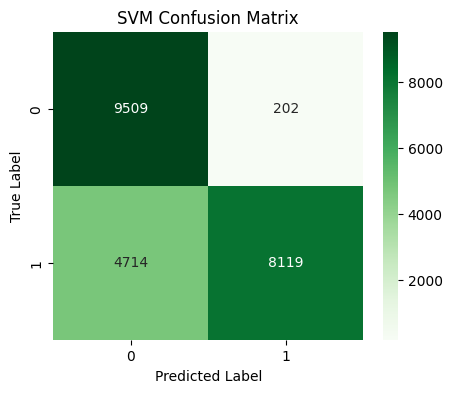

In [5]:
svm_cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Greens")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


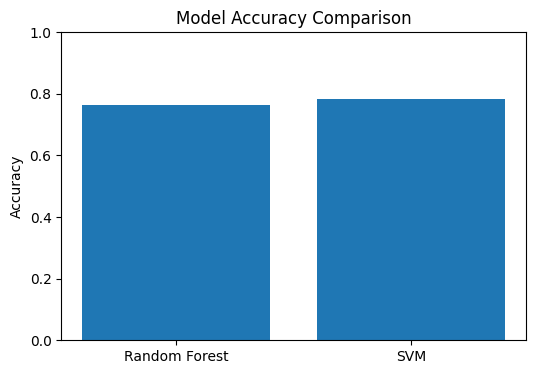

In [6]:
rf_accuracy = np.mean(rf_pred == y_test)
svm_accuracy = np.mean(svm_pred == y_test)

models = ["Random Forest", "SVM"]
accuracies = [rf_accuracy, svm_accuracy]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracies)
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


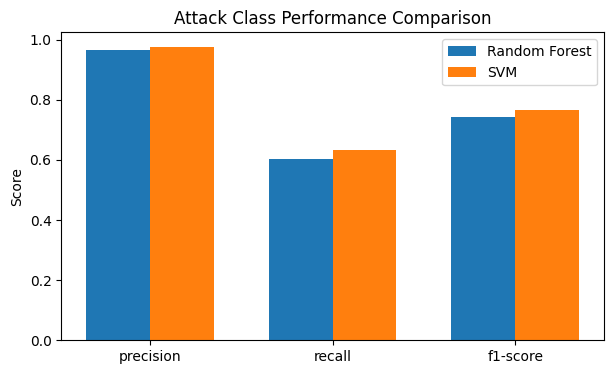

In [7]:
rf_report = classification_report(y_test, rf_pred, output_dict=True)
svm_report = classification_report(y_test, svm_pred, output_dict=True)

metrics = ["precision", "recall", "f1-score"]

rf_values = [rf_report["1"][m] for m in metrics]
svm_values = [svm_report["1"][m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, rf_values, width, label="Random Forest")
plt.bar(x + width/2, svm_values, width, label="SVM")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Attack Class Performance Comparison")
plt.legend()
plt.show()
